In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.13
macOS-15.5-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
old_base_sim_dir=f"sims-2025-05-31 mu_c sigma_c blur"
base_sim_dir=f"sims-2025-06-03 mu_c"
if not os.path.exists(base_sim_dir):
    print("new")
    os.mkdir(base_sim_dir)
print(base_sim_dir)


sims-2025-06-03 mu_c


In [4]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [5]:
def deficit(blur=[2.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day,
           save_interval=1*hour):


    print("sigma_c",sigma_c)
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]


@ray.remote
def run_one_deficit(params,run=True,overwrite=False):
    import plasticnet as pn
    noise,blur,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,sfname=(
                                params.noise,
                                params.blur,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 noise=noise,blur=blur,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 


    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [6]:
number_of_neurons=20
eta=1e-6
number_of_processes=8
ray.init(num_cpus=number_of_processes)

2025-06-04 11:43:44,642	INFO worker.py:1852 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.44.1


(pid=92010) Splikes version  0.1.4
(pid=92010) Plasticnet version  0.1.13
(run_one_deficit pid=92010) sigma_c 0
(run_one_deficit pid=92010) [
(run_one_deficit pid=92010) .] Sequence Time Elapsed...1 m, 32.00 s
(run_one_deficit pid=92010) sigma_c 0
(run_one_deficit pid=92010) [
(run_one_deficit pid=92010) .] Sequence Time Elapsed...1 m, 31.54 s
(run_one_deficit pid=92010) sigma_c 0
(run_one_deficit pid=92010) [
(run_one_deficit pid=92010) .] Sequence Time Elapsed...1 m, 31.62 s
(run_one_deficit pid=92010) sigma_c 0
(run_one_deficit pid=92010) [
(run_one_deficit pid=92010) .] Sequence Time Elapsed...1 m, 31.49 s
(run_one_deficit pid=92010) sigma_c 0
(run_one_deficit pid=92010) [
(run_one_deficit pid=92010) .] Sequence Time Elapsed...1 m, 31.78 s
(run_one_deficit pid=92010) sigma_c 0
(run_one_deficit pid=92010) [
(run_one_deficit pid=92010) .] Sequence Time Elapsed...1 m, 31.27 s
(run_one_deficit pid=92010) sigma_c 2
(run_one_deficit pid=92010) [
(run_one_deficit pid=92010) .] Sequence Ti

In [7]:
def doit(p2):
    p=Struct()
    p.number_of_neurons=20
    p.mu_c=0
    p.sigma_c=0
    p.mu_r=0
    p.sigma_r=0
    p.blur=[-1,-1]
    p.eta=1e-6
    
    p.noise=(.1,.1)

    p.update(p2)
    
    p.sfname=base_sim_dir+f"/mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"

    results = [run_one_deficit.remote(p,overwrite=True)]
    sfnames=ray.get(results)
    
    sfname=sfnames[0]
    R=Results(sfname)
    
    subR=Struct()
    subR.t=R.t/day
    t=subR.t
    
    subR.y=R.y
    subR.θ=R.θ
    
    #idx1,idx2=[_[1] for _ in R.sequence_index]
    
    # subR.ODI=R.ODI
    subR.ORI=R.ORI
    subR.theta_mat=R.theta_mat
    subR.k_mat=R.k_mat
    #subR.LSFV=R.LSFV
    subR.SF_Var=R.SF_Var
    subR.max_SF=R.max_SF
    subR.sfname=sfname
    subR.sequence_index=R.sequence_index
    subR.idx=[0]+[_[-1] for _ in R.sequence_index]
    subR.W=R.W[subR.idx,::]
    
    figure()
    ims=R.W_image()
    
    for c in range(2):
        subplot(1,2,c+1)
        imshow(ims[c],cmap=cm.gray)
        grid(None)
        axis('off')
    
    figure()
    plot(R.t,R.θ);
    
    figure()
    hist(R.ODI[0,:])
    hist(R.ODI[-1,:],alpha=0.1)
    
    figure()
    plot(R.ODI);
    
    return R

## Running one with $\mu_c=0$ with blur -1, 0, and 1

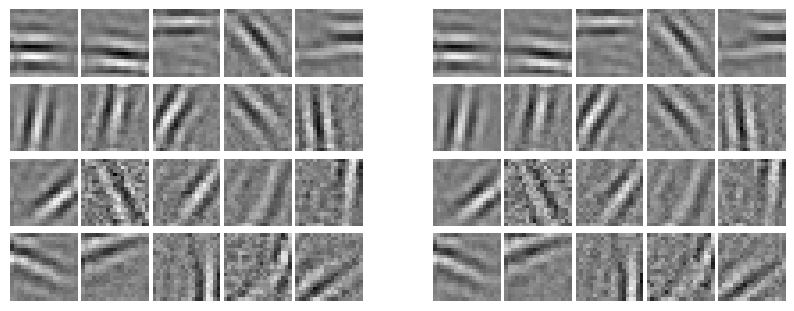

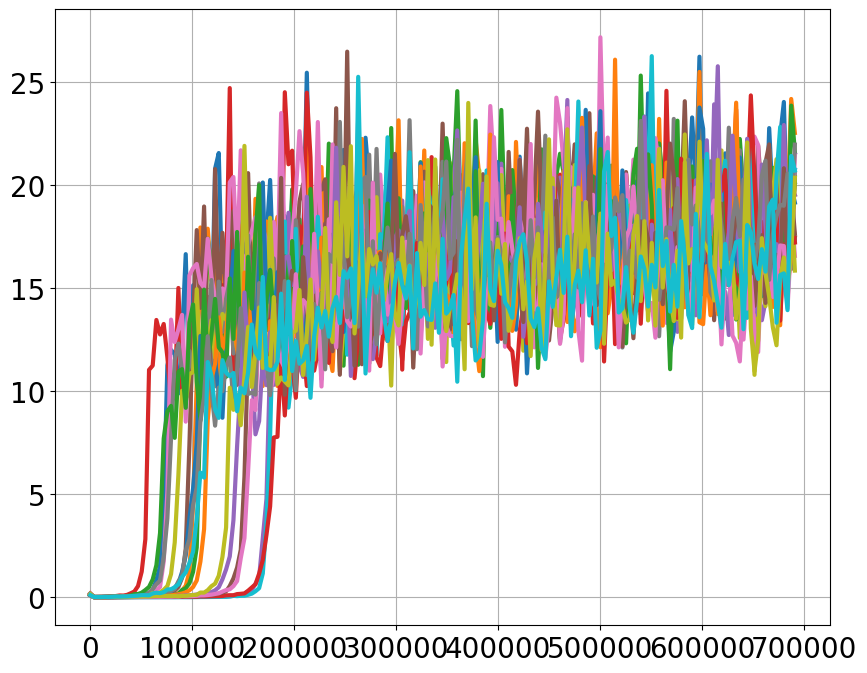

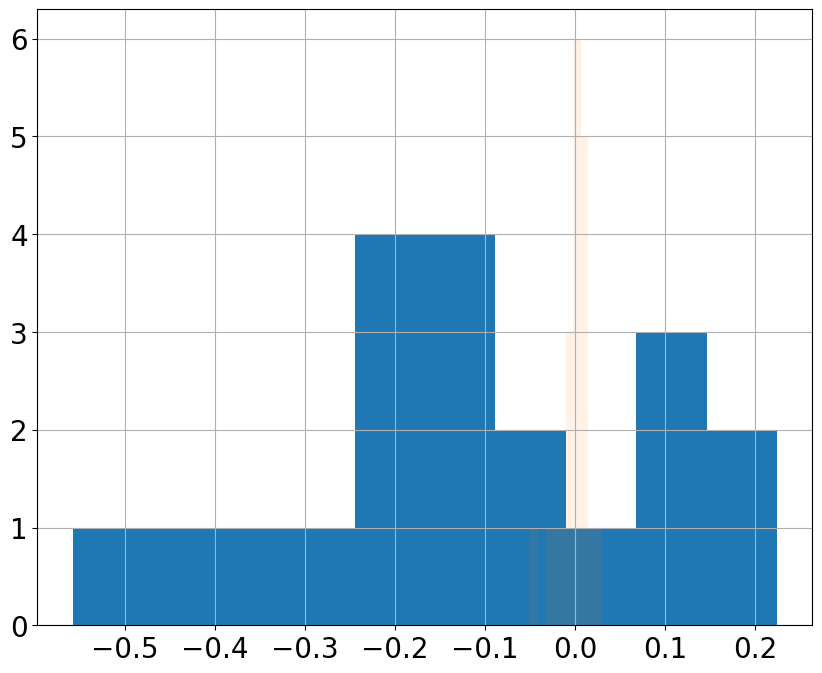

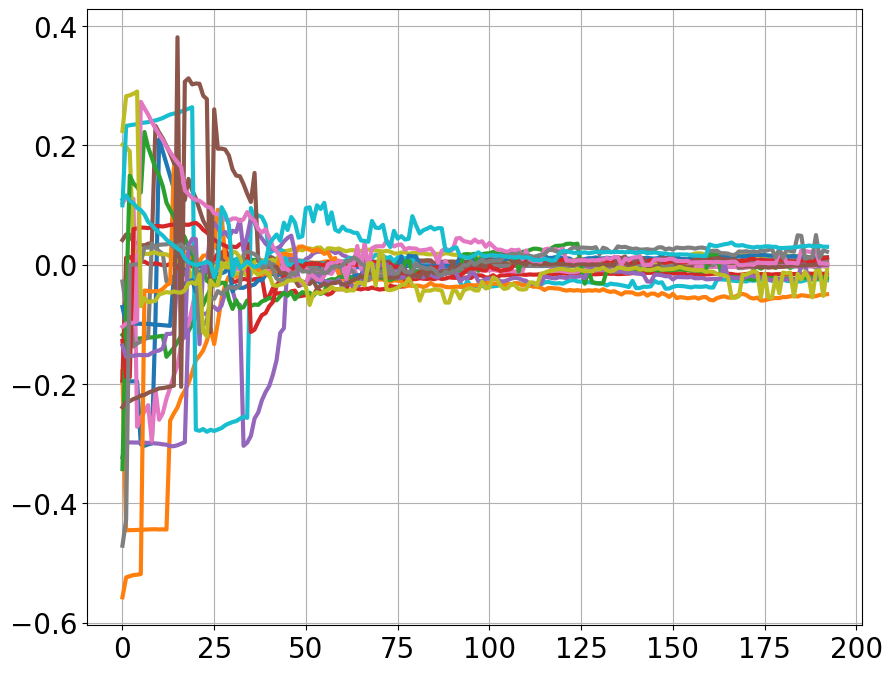

In [8]:
p=Struct()
p.blur=[-1,-1]
p.mu_c=0
p.sigma_c=0

R=doit(p)

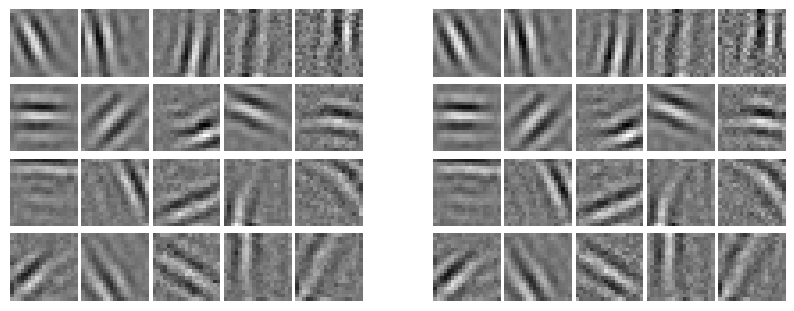

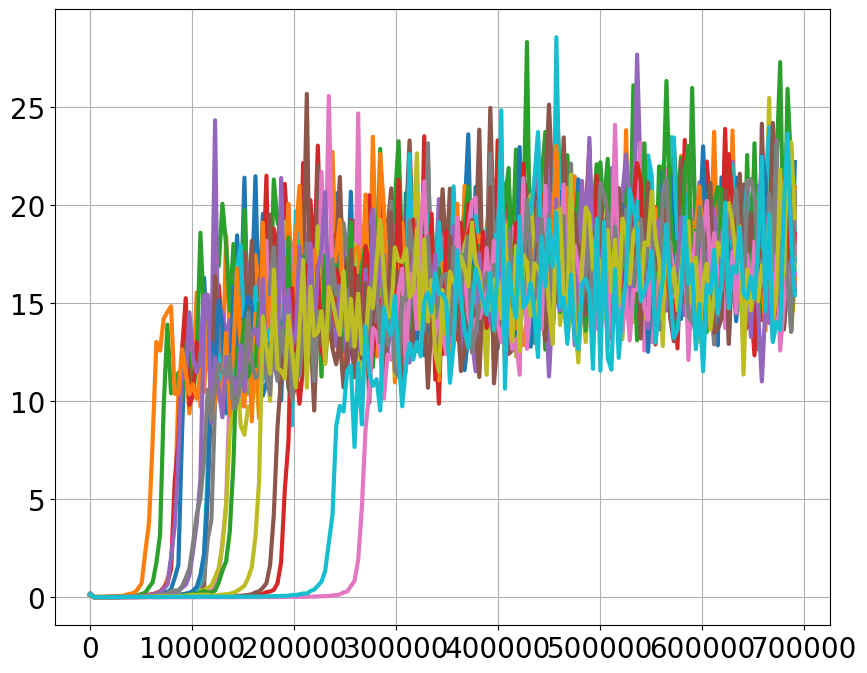

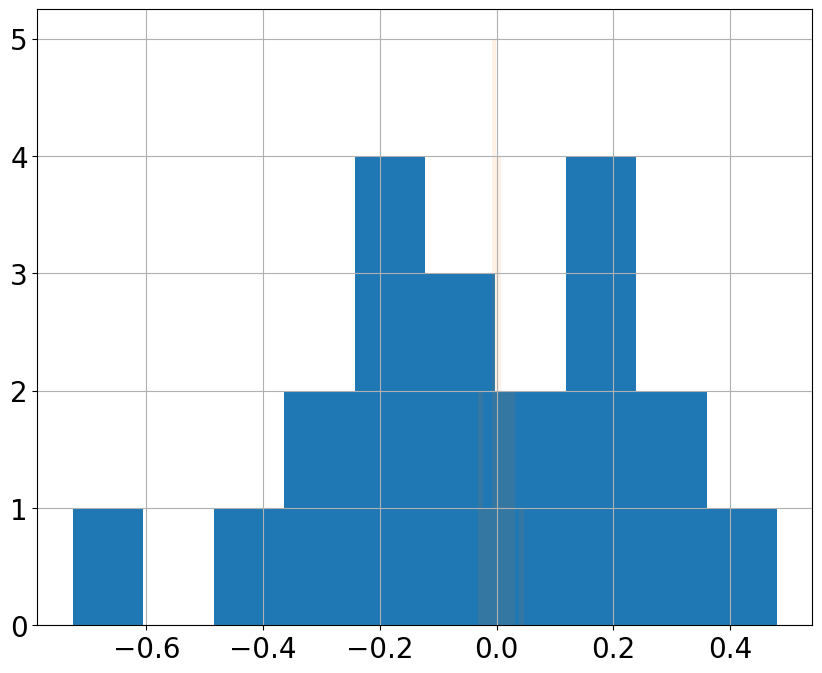

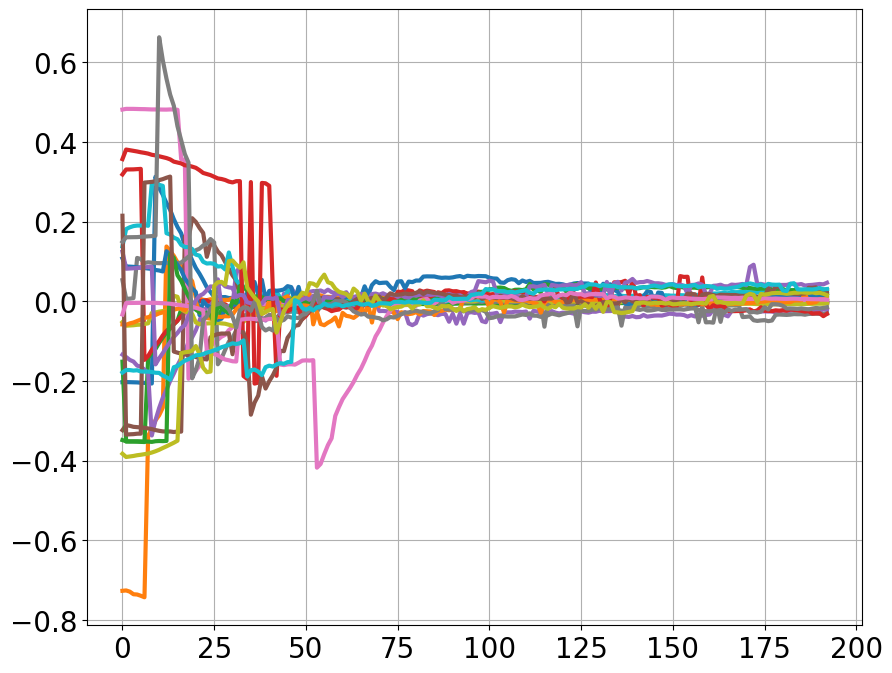

In [9]:
p=Struct()
p.blur=[0,-1]
p.mu_c=0
p.sigma_c=0

R=doit(p)

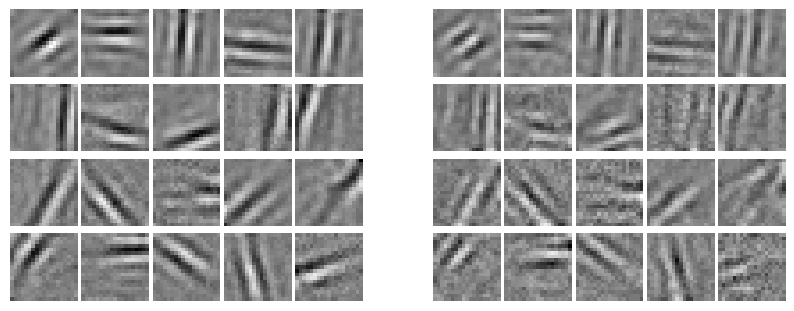

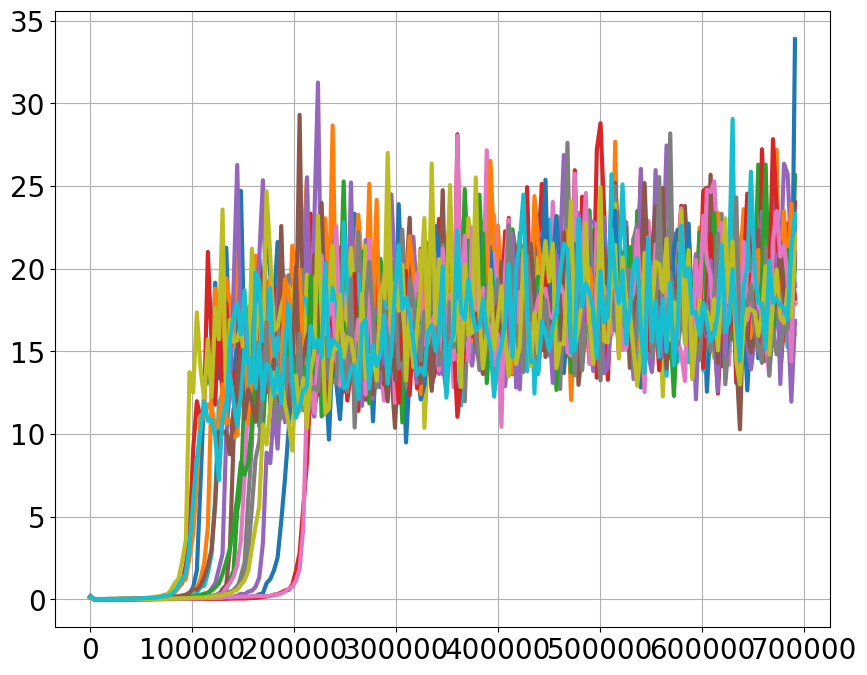

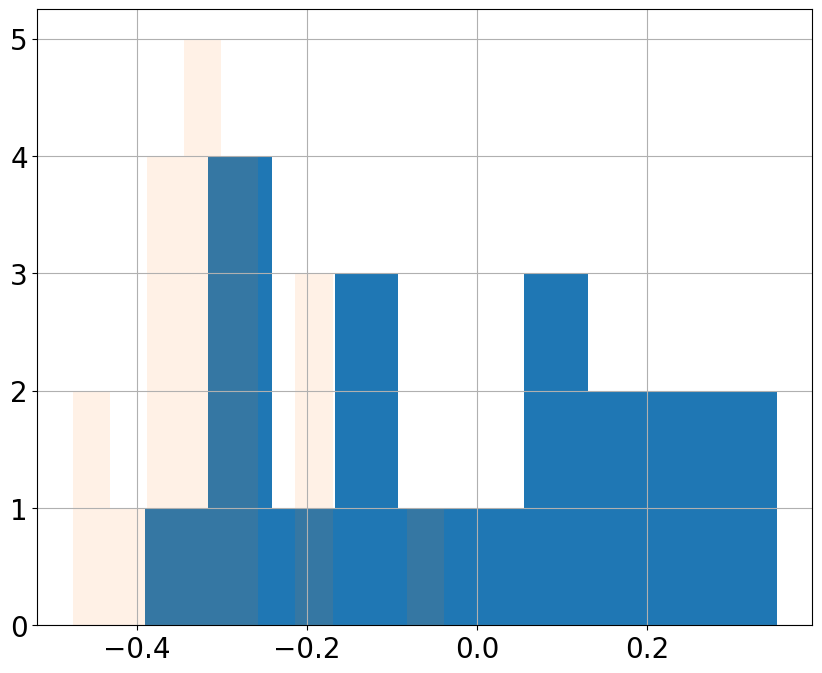

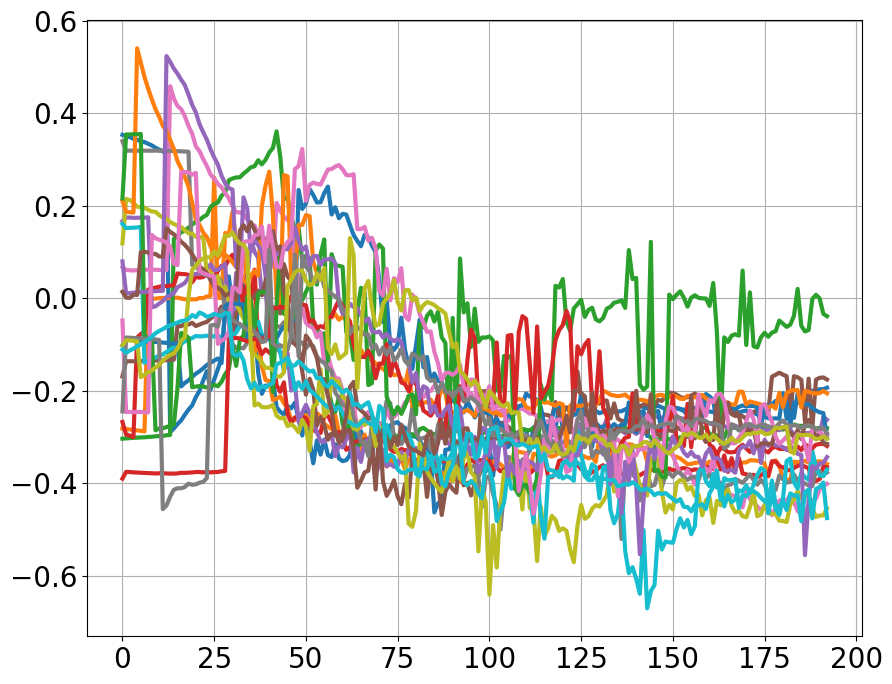

In [10]:
p=Struct()
p.blur=[1,-1]
p.mu_c=0
p.sigma_c=0

R=doit(p)

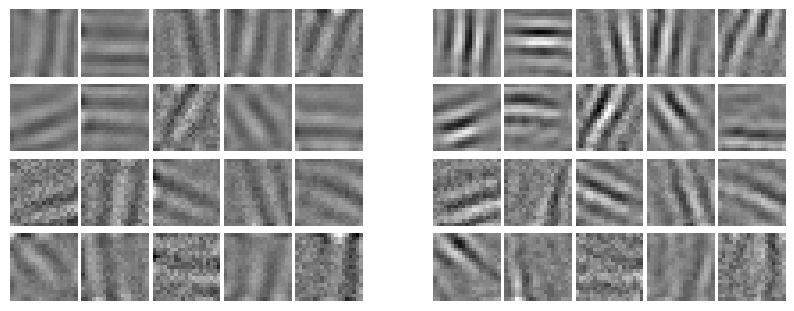

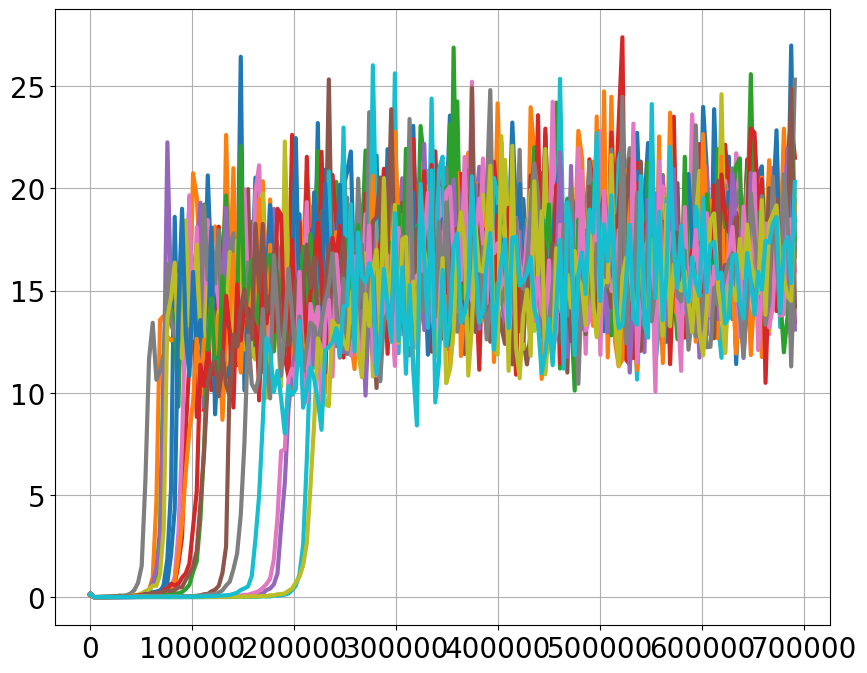

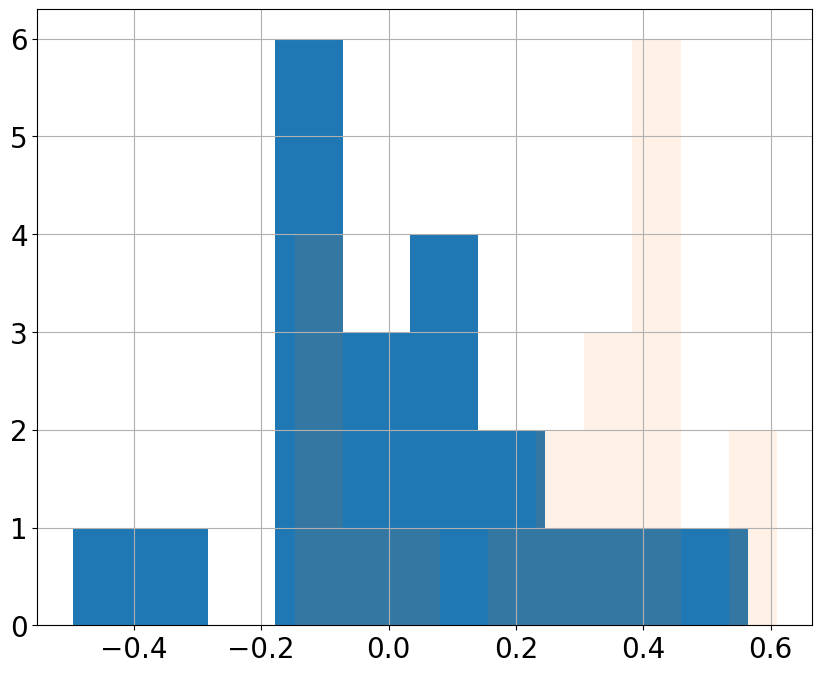

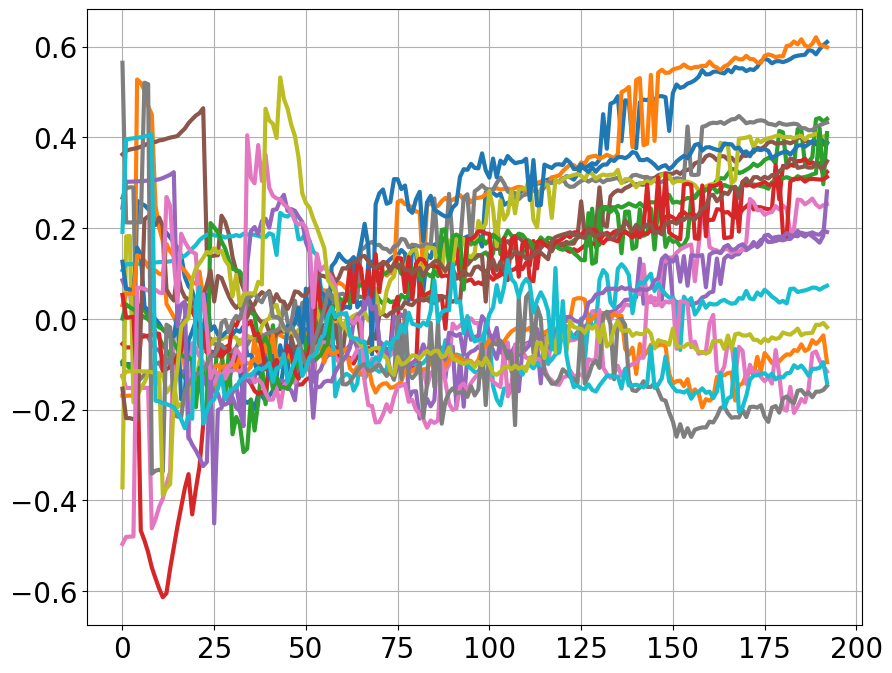

In [11]:
p=Struct()
p.blur=[2,-1]
p.mu_c=0
p.sigma_c=0

R=doit(p)

## What is the difference between blur -1 and 0?  None really.

In [12]:
blur=-1

if blur<0:
    im=pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
else:
    im=pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':blur},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
im=pi5.asdf_load_images(im)
im_1=[_*im['im_scale_shift'][0]+im['im_scale_shift'][1] for _ in im['im']]
[(_.std(),_.mean()) for _ in im_1]

[(0.9999995689357944, -0.0003287202767132242),
 (0.9999995157402886, -0.0003271146477992378),
 (0.9999997691293467, -0.00032728013044496743),
 (0.9999999371038284, -0.0003270132710432935),
 (1.0000004343682867, -0.00032702519772046196),
 (1.0000001686045132, -0.00032701178020864334),
 (1.000000267220755, -0.0003268999676101804),
 (0.9999995991901395, -0.0003271429736575123),
 (1.0000001347572418, -0.00032656900231871816),
 (1.0000000814064678, -0.0003272398779095159),
 (0.9999993993844529, -0.00032761258657107553),
 (1.000000281792337, -0.00032746201227180775),
 (1.000000321368358, -0.00032684927923220836),
 (0.9999997308381103, -0.0003272443504134563),
 (0.9999999152997596, -0.0003266480165549675),
 (0.9999998828342794, -0.00032672852162586347),
 (0.9999996691271471, -0.00032699389019288965),
 (1.0000003779254008, -0.0003274724481143255),
 (1.0000001755131505, -0.00032754251734270123),
 (1.0000000629043237, -0.0003272324237362887),
 (1.0000000466154582, -0.00032714893699609885),
 (1.0

In [13]:
blur=0

if blur<0:
    im=pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
else:
    im=pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':blur},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
im=pi5.asdf_load_images(im)
im_0=[_*im['im_scale_shift'][0]+im['im_scale_shift'][1] for _ in im['im']]
[(_.std(),_.mean()) for _ in im_0]

[(0.9999995689357943, -0.0003287202767164194),
 (0.9999995157402884, -0.0003271146478024251),
 (0.9999997691293466, -0.00032728013044815596),
 (0.9999999371038283, -0.00032701327104647993),
 (1.0000004343682865, -0.00032702519772364865),
 (1.0000001686045132, -0.00032701178021183176),
 (1.0000002672207549, -0.0003268999676133668),
 (0.9999995991901395, -0.0003271429736607017),
 (1.0000001347572416, -0.0003265690023219063),
 (1.0000000814064676, -0.0003272398779127057),
 (0.9999993993844529, -0.0003276125865742622),
 (1.000000281792337, -0.0003274620122749972),
 (1.000000321368358, -0.0003268492792353926),
 (0.9999997308381101, -0.0003272443504166449),
 (0.9999999152997593, -0.00032664801655815493),
 (0.9999998828342793, -0.00032672852162905015),
 (0.9999996691271471, -0.00032699389019607585),
 (1.0000003779254005, -0.0003274724481175179),
 (1.0000001755131505, -0.00032754251734588857),
 (1.0000000629043235, -0.0003272324237394783),
 (1.000000046615458, -0.00032714893699929036),
 (1.000

Text(0.5, 1.0, 'Blur=0')

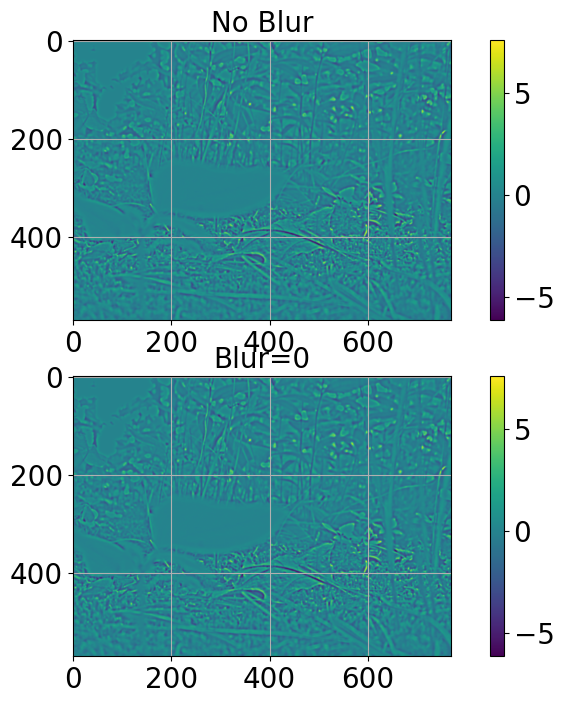

In [14]:
subplot(2,1,1)
imshow(im_1[0])
colorbar()
title('No Blur')

subplot(2,1,2)
imshow(im_0[0])
colorbar()
title('Blur=0')

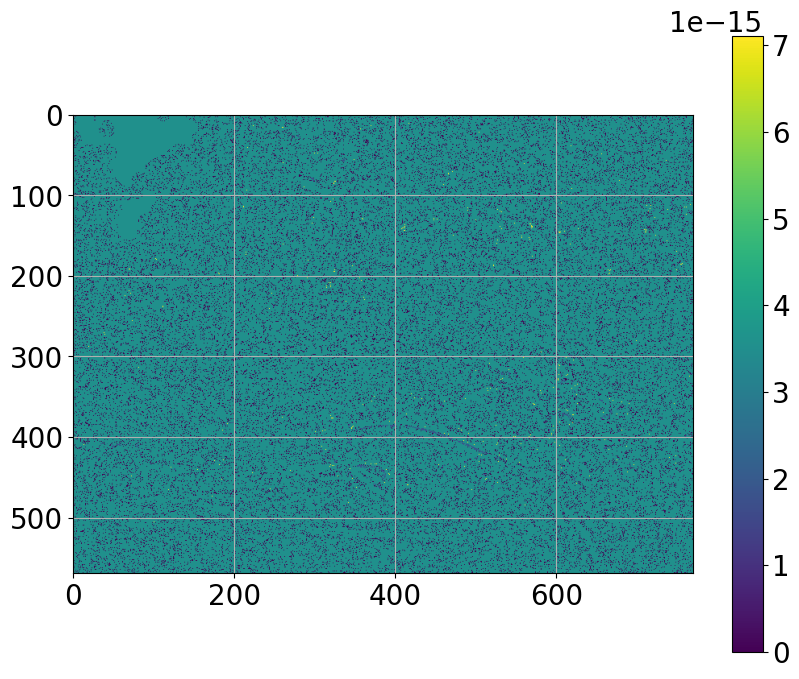

In [15]:
imshow(im_1[0]-im_0[0])
colorbar()

## Why does blur=1 cause an OD shift toward the amblyopic eye but blur=2 causes an OD shift toward the fellow eye?

No idea, but the threshold is higher in the blur=1 case

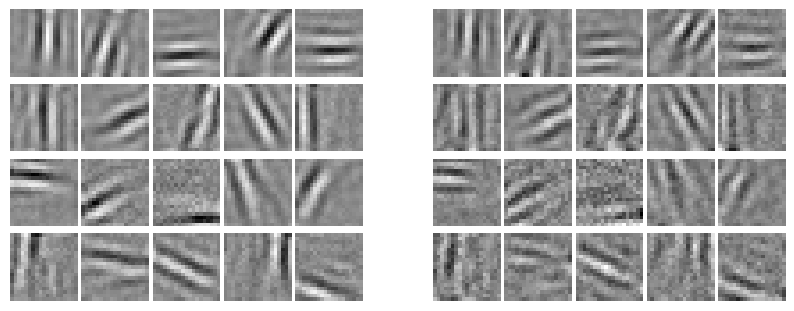

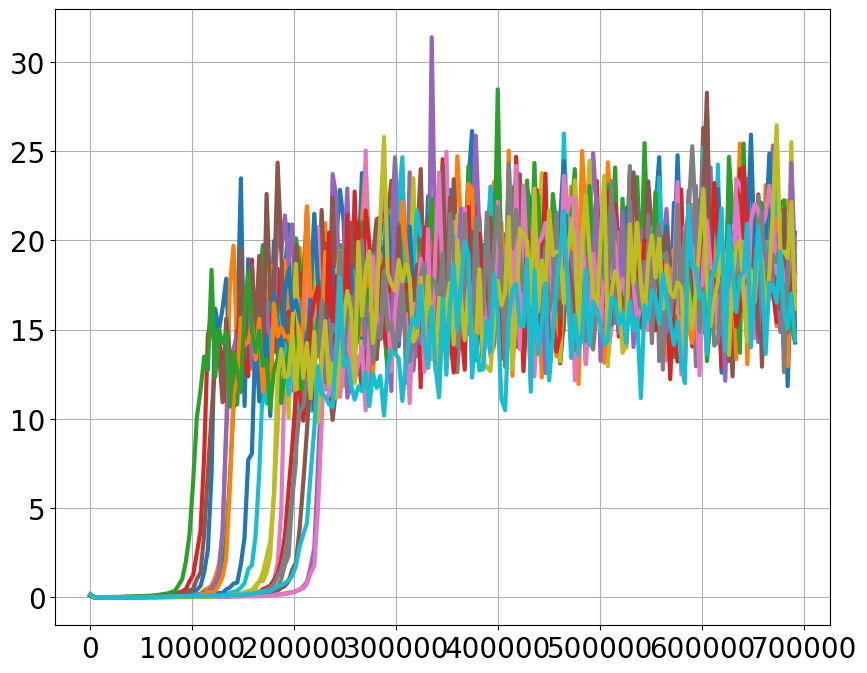

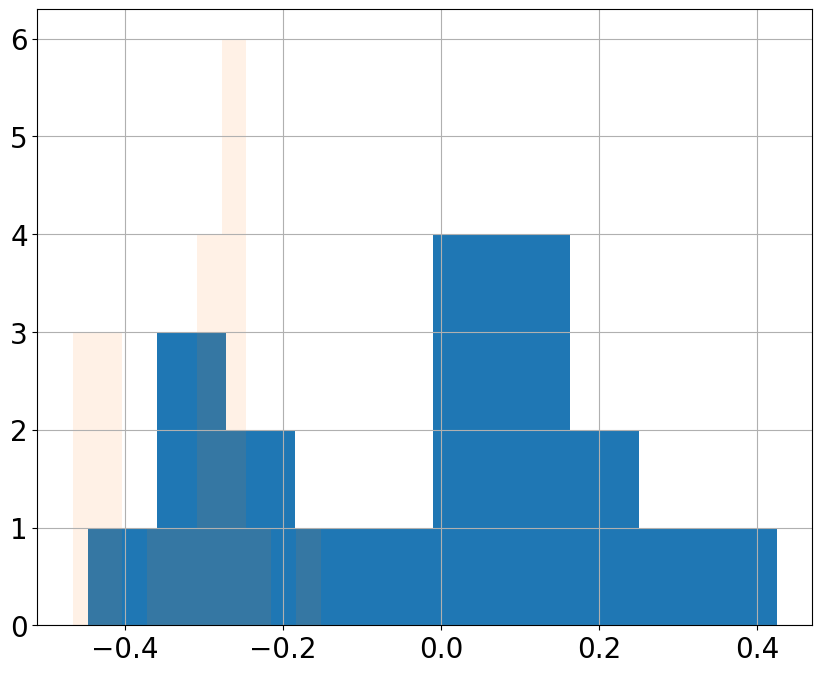

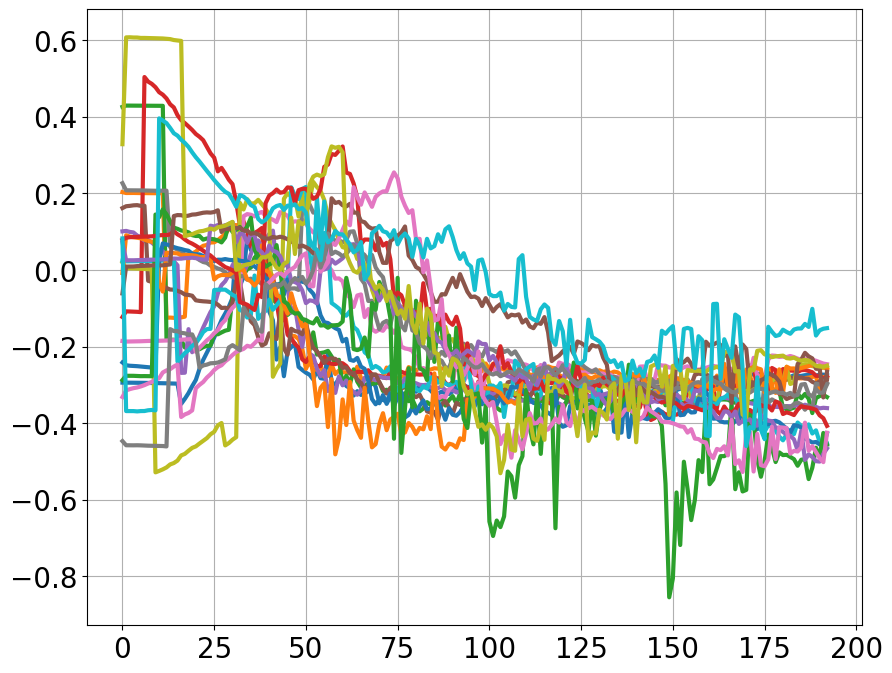

In [16]:
p=Struct()
p.blur=[1,-1]
p.mu_c=0
p.sigma_c=0

R1=doit(p)

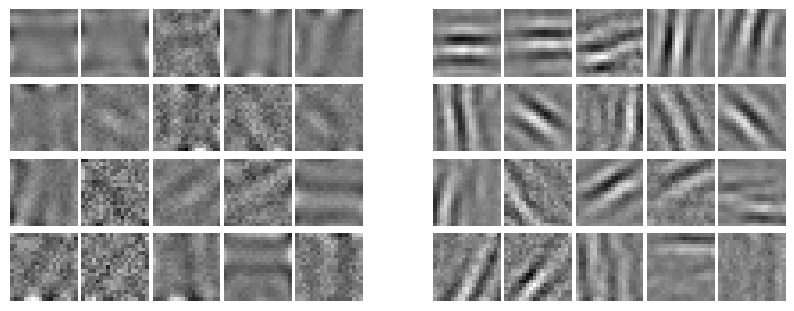

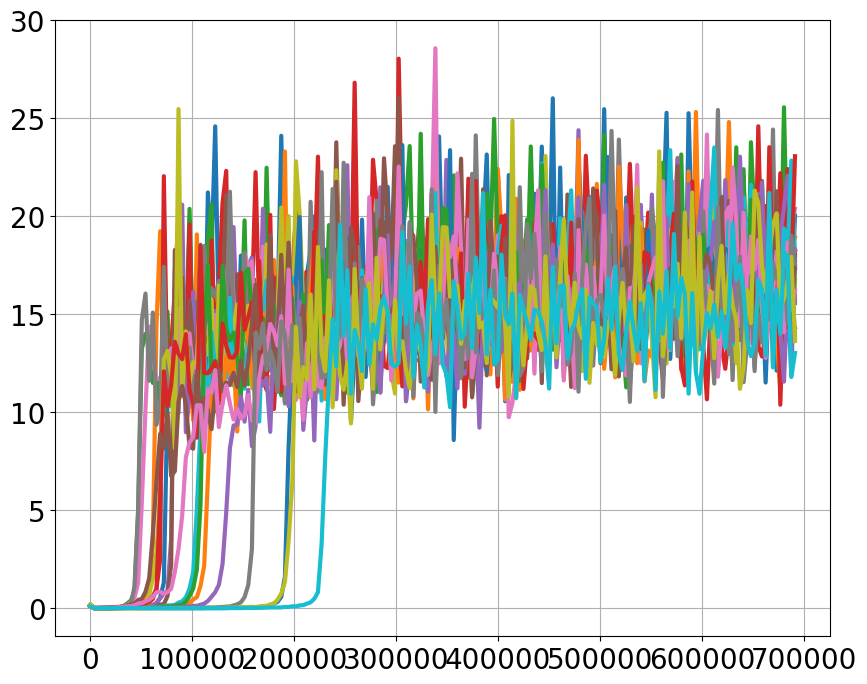

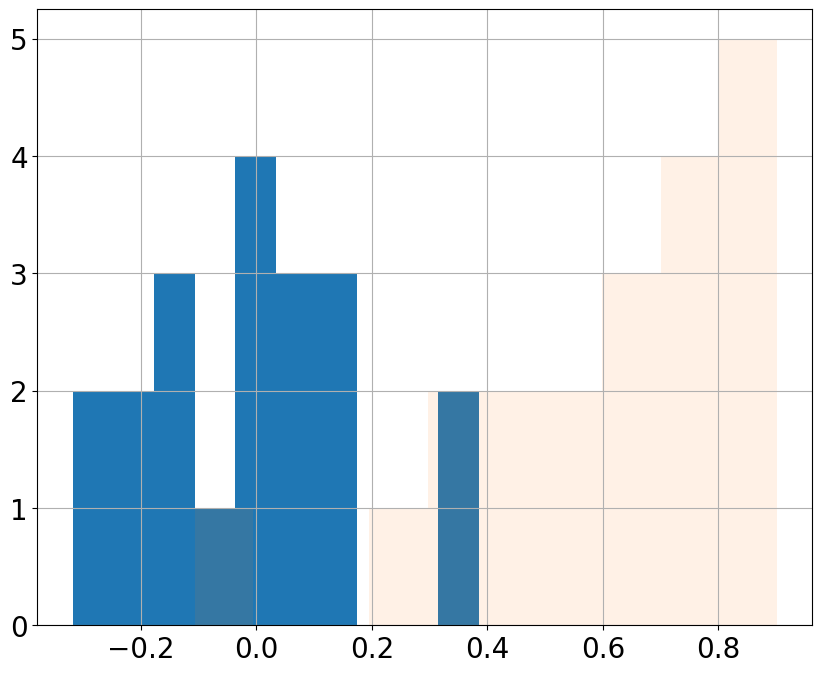

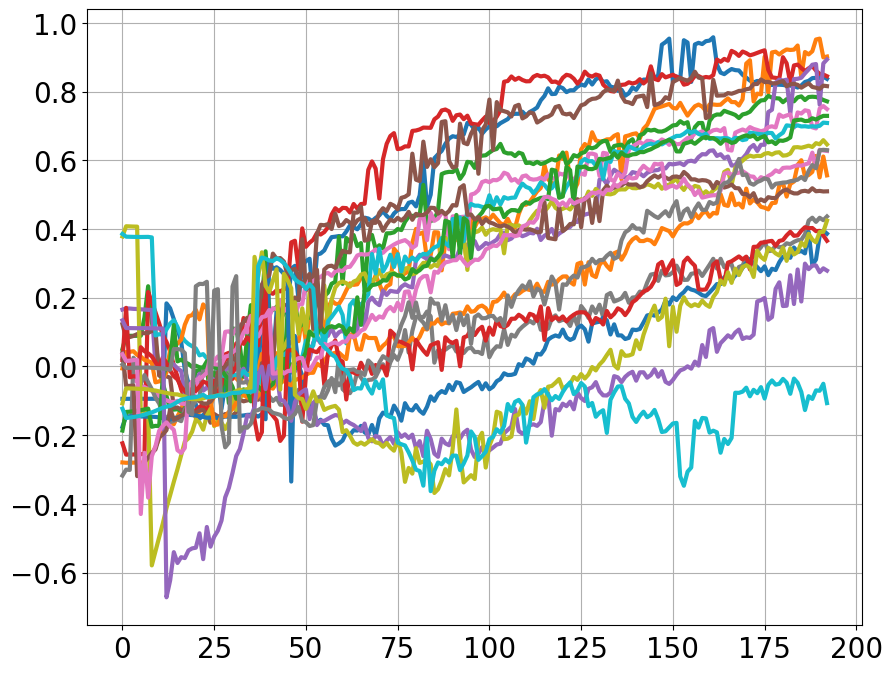

In [17]:
p=Struct()
p.blur=[2.5,-1]
p.mu_c=0
p.sigma_c=0

R2=doit(p)

## Maybe the difference is reduced with sigma_c>0?

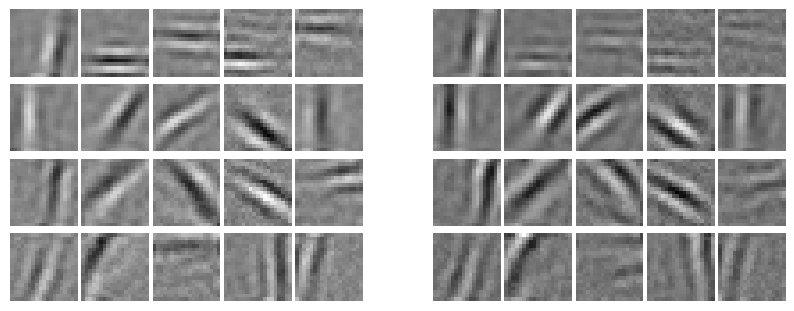

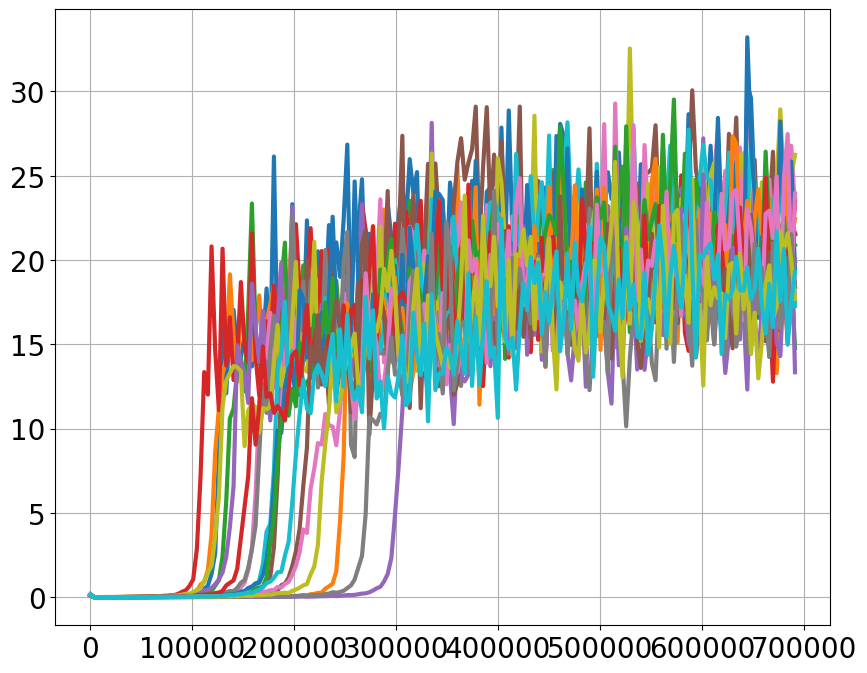

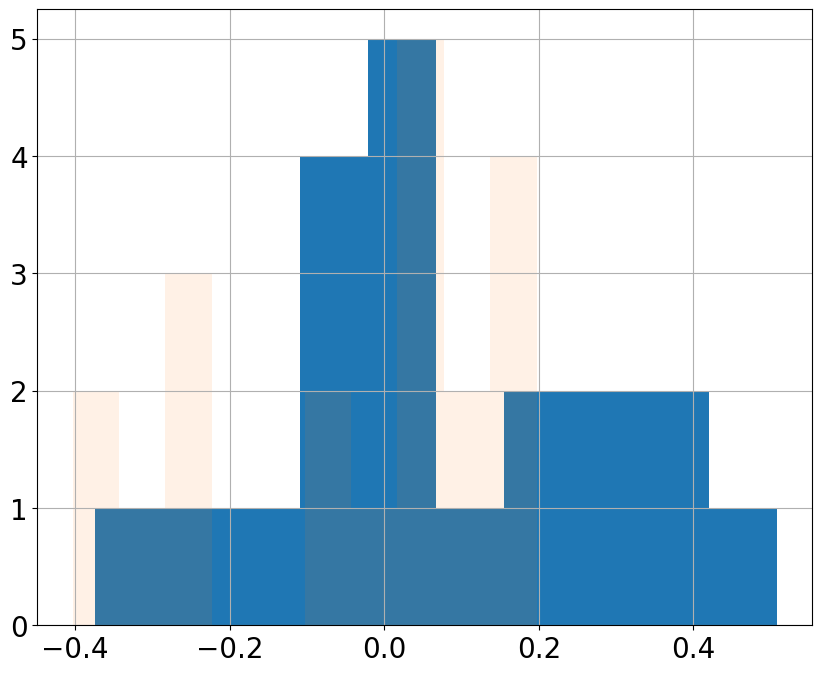

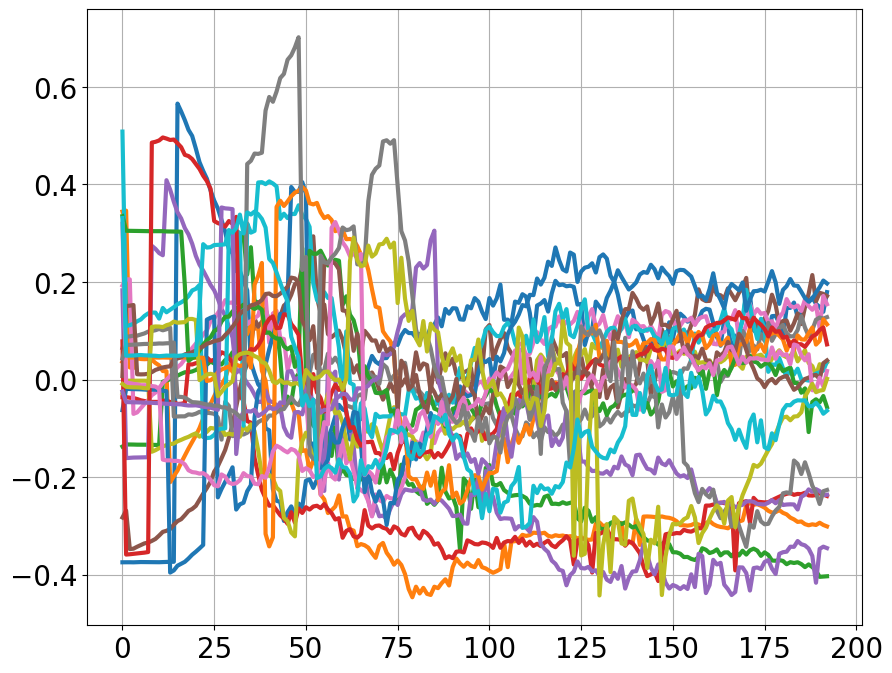

In [18]:
p=Struct()
p.blur=[1,-1]
p.mu_c=0
p.sigma_c=2

R1=doit(p)

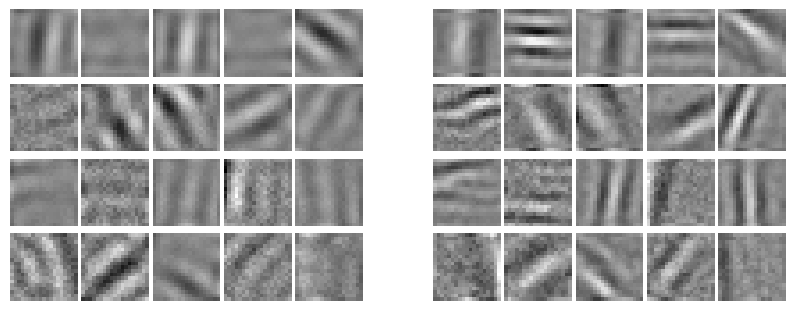

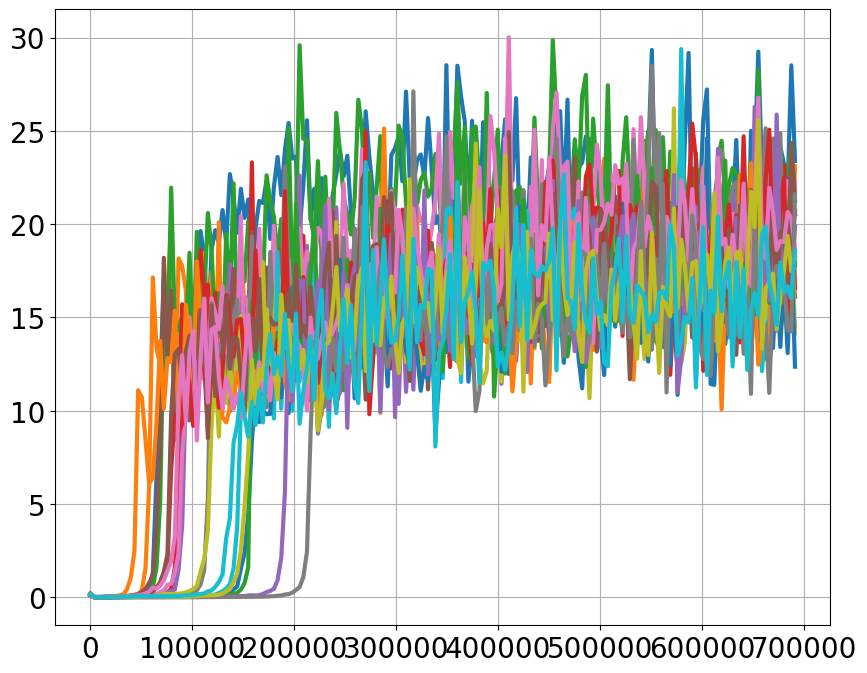

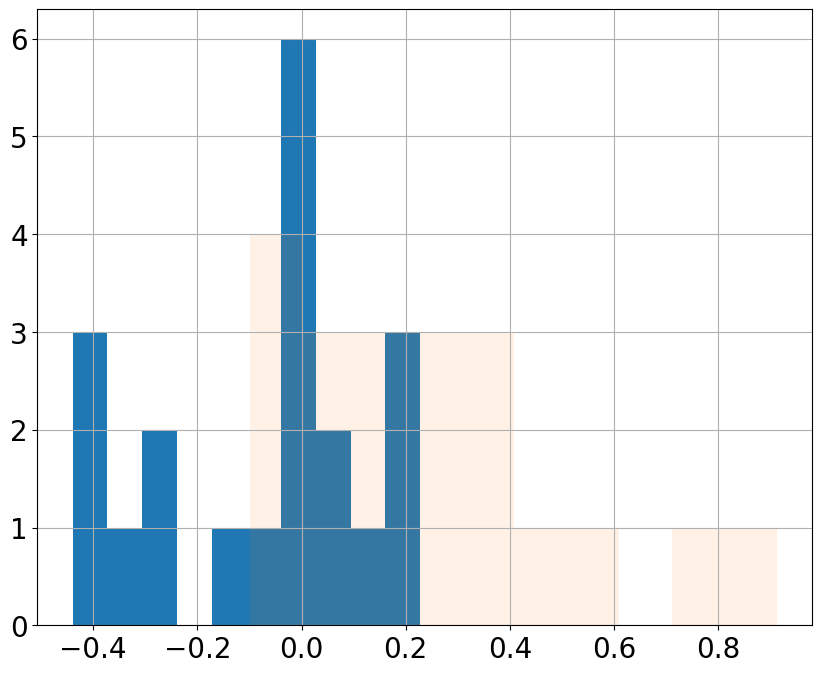

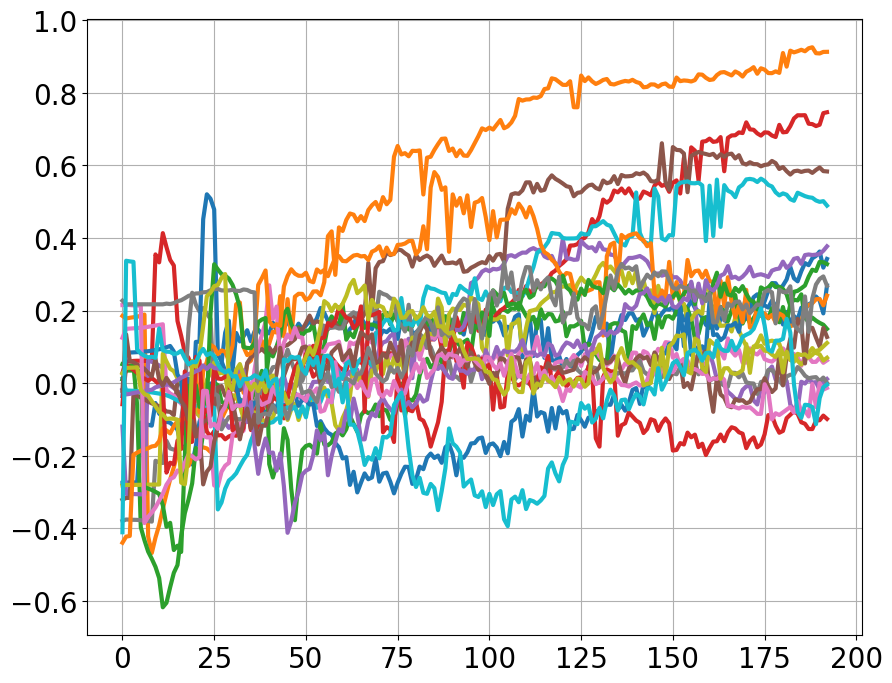

In [19]:
p=Struct()
p.blur=[2.5,-1]
p.mu_c=0
p.sigma_c=2

R2=doit(p)

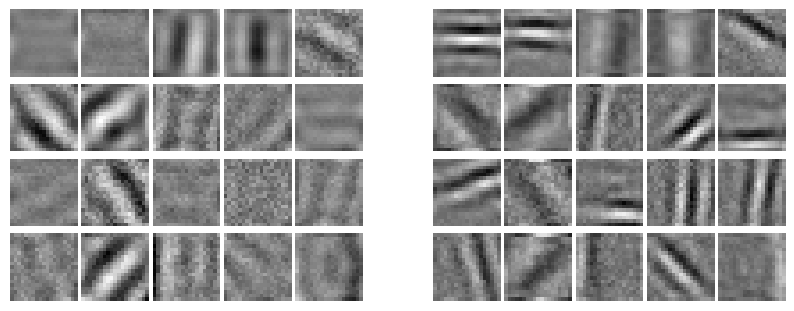

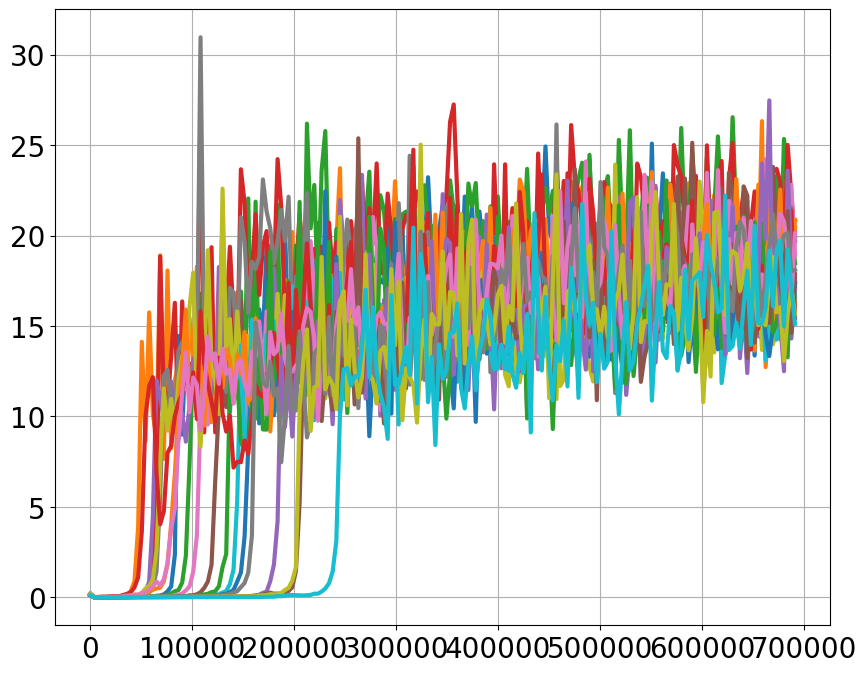

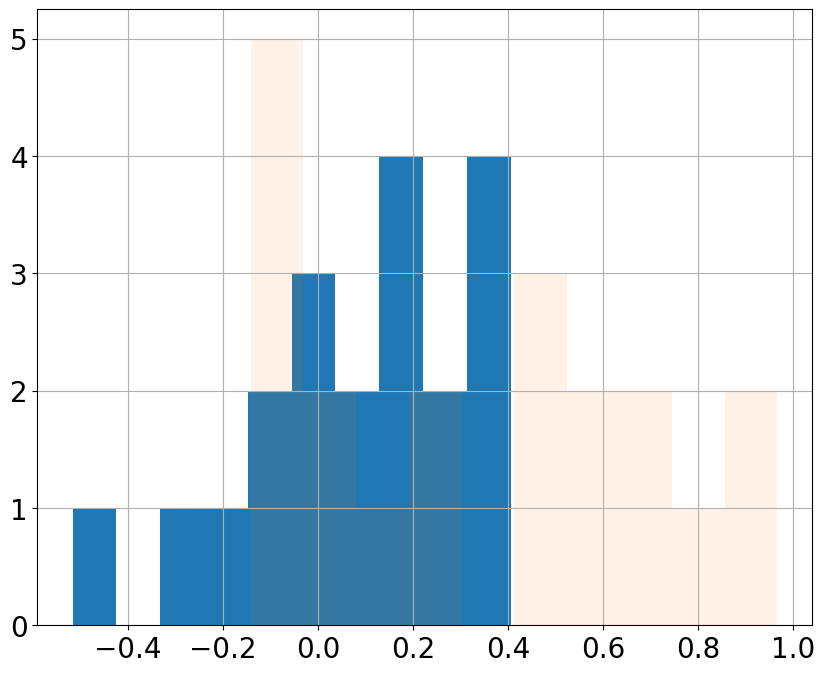

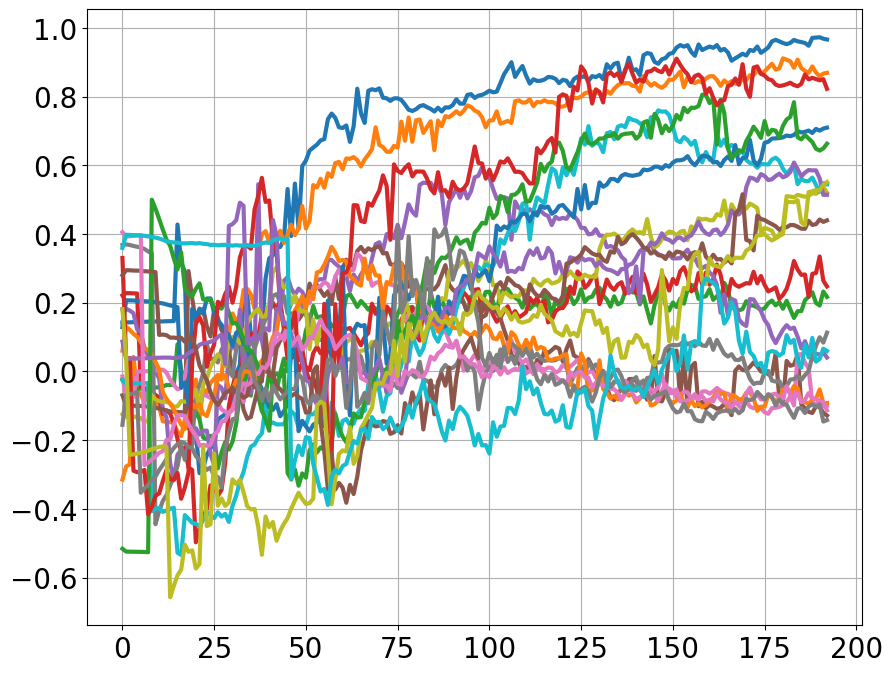

In [20]:
p=Struct()
p.blur=[3,-1]
p.mu_c=0
p.sigma_c=2

R2=doit(p)